<a href="https://colab.research.google.com/github/sardar-ammad-143/Basic-Python/blob/main/SUMMARY%20REMOVE%20PM10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install tensorflow scikit-learn pandas numpy

In [3]:
# Load the dataset from the sample_data directory
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Replace 'your_dataset.csv' with the actual name of your uploaded file
data = pd.read_csv('/content/sample_data/Measurement.csv')

print("Dataset Uploaded")

Dataset Uploaded


In [4]:
# Get the number of instances (rows) and attributes (columns)
num_instances = data.shape[0]  # Number of rows
num_attributes = data.shape[1]  # Number of columns

# Print the results
print(f'Total number of instances (rows): {num_instances}')
print(f'Total number of attributes (columns): {num_attributes}')

# Get the data types of the columns
data_types = data.dtypes

# Print the data types
print(data_types)

Total number of instances (rows): 647511
Total number of attributes (columns): 5
SO2      float64
NO2      float64
O3       float64
CO       float64
PM2.5      int64
dtype: object


In [5]:
# Summary statistics for numerical columns
summary_statistics = data.describe()
print(summary_statistics)

                 SO2            NO2             O3             CO  \
count  647511.000000  647511.000000  647511.000000  647511.000000   
mean       -0.001795       0.022519       0.017979       0.509197   
std         0.078832       0.115153       0.099308       0.405319   
min        -1.000000      -1.000000      -1.000000      -1.000000   
25%         0.003000       0.016000       0.008000       0.300000   
50%         0.004000       0.025000       0.021000       0.500000   
75%         0.005000       0.038000       0.034000       0.600000   
max         3.736000      38.445000      33.600000      71.700000   

               PM2.5  
count  647511.000000  
mean       25.411995  
std        43.924595  
min        -1.000000  
25%        11.000000  
50%        19.000000  
75%        31.000000  
max      6256.000000  


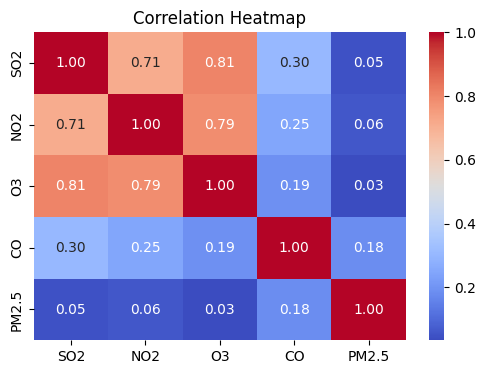

In [6]:
# Calculate the correlation matrix
correlation_matrix = data.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load the dataset
df = pd.read_csv("/content/sample_data/Measurement.csv")

# Define independent variables (features) and target variable
X = df[["SO2", "NO2", "CO", "O3"]]
y = df["PM2.5"]

# Handle missing values if present
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize the features to the range [0, 1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define the neural network model
model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='sigmoid'),
    Dense(16, activation='sigmoid'),
    Dense(1, activation='linear')  # Linear activation for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    verbose=1
)

# Save the trained model to a file
model.save("/content/air_quality_model2.h5")  # Replace with your desired file path

# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Output the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7083/7083 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 2196.9182 - val_loss: 1873.3816
Epoch 2/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1913.1028 - val_loss: 1873.4250
Epoch 3/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 2004.9341 - val_loss: 1873.4674
Epoch 4/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 1883.5095 - val_loss: 1873.3510
Epoch 5/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1982.2637 - val_loss: 1871.4149
Epoch 6/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 2055.8586 - val_loss: 1848.9684
Epoch 7/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 1801.4884 - val_loss: 1770.1949
Epoch 8/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 2112.5371 - val_loss: 1749.6455
Epoch 9/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 1761.6049 - val_loss: 1747.6492
Epoch 10/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 1797.9287 - val_loss: 1748.1383
Epoch 11/50
7083/7083 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - lo

3036/3036 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Mean Absolute Error (MAE): 12.217341423034668
Root Mean Squared Error (RMSE): 41.89338740425659
R² Score: 0.06826406717300415


In [11]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Assuming you already have X_train (the feature set for training)
scaler = MinMaxScaler()
scaler.fit(X_train)  # Fit the scaler to the training data

# Save the fitted scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [12]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("air_quality_model2.h5", custom_objects={"mse": "MeanSquaredError"})

# Load the fitted scaler
scaler = joblib.load("scaler.pkl")  # Load the saved scaler

# Function to predict PM2.5 in real time
def predict_pm25(SO2, NO2, O3, CO):
    # Input values as a NumPy array
    input_data = np.array([[SO2, NO2, O3, CO]])

    # Scale the input data using the fitted scaler
    input_scaled = scaler.transform(input_data)

    # Predict using the trained model
    prediction = model.predict(input_scaled)

    # Return the predicted PM2.5 value
    return prediction[0][0]

# Example real-time input values
real_time_values = {
    "SO2": 0.004,
    "NO2": 0.047,
    "O3": 0.002,
    "CO": 1.1
}

# Predict PM2.5 for the given values
predicted_pm25 = predict_pm25(
    real_time_values["SO2"],
    real_time_values["NO2"],
    real_time_values["O3"],
    real_time_values["CO"]
)

def categorize_pm25(pm25_value):
    """
    Categorizes the PM2.5 value into air quality levels with associated colors.

    Parameters:
        pm25_value (float): The real-time PM2.5 value.

    Returns:
        dict: A dictionary containing the category and associated color.
    """
    if pm25_value <= 15:
        return {"category": "Good", "color": "Blue"}
    elif pm25_value <= 35:
        return {"category": "Normal", "color": "Green"}
    elif pm25_value <= 75:
        return {"category": "Bad", "color": "Yellow"}
    else:
        return {"category": "Very Bad", "color": "Red"}

# Example usage:
real_time_pm25 = 40  # Replace with the real-time PM2.5 value
result = categorize_pm25(real_time_pm25)

print(f"PM2.5 Value: {real_time_pm25}")
print(f"Category: {result['category']}, Color: {result['color']}")



# Categorize the predicted value
category_result = categorize_pm25(predicted_pm25)

print(f"Predicted PM2.5 Value: {predicted_pm25}")
print(f"Air Quality: {category_result['category']}")
print(f"Color Code: {category_result['color']}")





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


PM2.5 Value: 40
Category: Bad, Color: Yellow
Predicted PM2.5 Value: 35.9610710144043
Air Quality: Bad
Color Code: Yellow


In [14]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("air_quality_model2.h5", custom_objects={"mse": "MeanSquaredError"})

# Load the fitted scaler
scaler = joblib.load("scaler.pkl")  # Load the saved scaler

# Function to predict PM2.5 in real time
def predict_pm25(SO2, NO2, O3, CO):
    """
    Predicts PM2.5 using the trained model and the scaled input data.

    Parameters:
        SO2, NO2, O3, CO (float): Real-time pollutant levels.

    Returns:
        float: Predicted PM2.5 value.
    """
    # Input values as a NumPy array
    input_data = np.array([[SO2, NO2, O3, CO]])

    # Scale the input data using the fitted scaler
    input_scaled = scaler.transform(input_data)

    # Predict using the trained model
    prediction = model.predict(input_scaled)

    # Return the predicted PM2.5 value
    return prediction[0][0]

# Function to categorize PM2.5 values
def categorize_pm25(pm25_value):
    """
    Categorizes the PM2.5 value into air quality levels with associated colors.

    Parameters:
        pm25_value (float): The real-time PM2.5 value.

    Returns:
        dict: A dictionary containing the category and associated color.
    """
    if pm25_value <= 15:
        return {"category": "Good", "color": "Blue"}
    elif pm25_value <= 35:
        return {"category": "Normal", "color": "Green"}
    elif pm25_value <= 75:
        return {"category": "Bad", "color": "Yellow"}
    else:
        return {"category": "Very Bad", "color": "Red"}

# Real-time data for multiple locations
locations_data = [
    {"location": "Rawalpindi", "SO2": 0.004, "NO2": 0.047, "O3": 0.002, "CO": 1.1},
    {"location": "Jhelum", "SO2": 0.01, "NO2": 0.08, "O3": 0.005, "CO": 1.5},
    {"location": "Attock", "SO2": 0.002, "NO2": 0.03, "O3": 0.001, "CO": 0.9},
    {"location": "Murree", "SO2": 0.008, "NO2": 0.06, "O3": 0.004, "CO": 1.3},
    {"location": "Chakwal", "SO2": 0.004, "NO2": 0.017, "O3": 0.008, "CO": 0.3},

]

# Process each location and output predictions with categorization
for data in locations_data:
    predicted_pm25 = predict_pm25(data["SO2"], data["NO2"], data["O3"], data["CO"])
    category_result = categorize_pm25(predicted_pm25)

    print(f"Location: {data['location']}")
    print(f"Predicted PM2.5 Value: {predicted_pm25:.2f}")
    print(f"Air Quality: {category_result['category']} ({category_result['color']})\n")


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Location: Rawalpindi
Predicted PM2.5 Value: 35.96
Air Quality: Bad (Yellow)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Location: Jhelum
Predicted PM2.5 Value: 50.90
Air Quality: Bad (Yellow)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Location: Attock
Predicted PM2.5 Value: 27.31
Air Quality: Normal (Green)



/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Location: Murree
Predicted PM2.5 Value: 44.22
Air Quality: Bad (Yellow)



/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Location: Chakwal
Predicted PM2.5 Value: 12.50
Air Quality: Good (Blue)



In [15]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("air_quality_model2.h5", custom_objects={"mse": "MeanSquaredError"})

# Load the fitted scaler
scaler = joblib.load("scaler.pkl")  # Load the saved scaler

# Function to predict PM2.5 in real-time (µg/m³)
def predict_pm25(SO2, NO2, O3, CO):
    """
    Predicts PM2.5 (µg/m³) using the trained model and the scaled input data.

    Parameters:
        SO2, NO2, O3, CO (float): Real-time pollutant levels.

    Returns:
        float: Predicted PM2.5 value in µg/m³.
    """
    # Input values as a NumPy array
    input_data = np.array([[SO2, NO2, O3, CO]])

    # Scale the input data using the fitted scaler
    input_scaled = scaler.transform(input_data)

    # Predict using the trained model
    prediction = model.predict(input_scaled)

    # Return the predicted PM2.5 value in µg/m³
    return prediction[0][0]

# Function to categorize PM2.5 values (µg/m³)
def categorize_pm25(pm25_value):
    """
    Categorizes the PM2.5 value (µg/m³) into air quality levels with associated colors.

    Parameters:
        pm25_value (float): The real-time PM2.5 value in µg/m³.

    Returns:
        dict: A dictionary containing the category and associated color.
    """
    if pm25_value <= 15:
        return {"category": "Good", "color": "Blue"}
    elif pm25_value <= 35:
        return {"category": "Normal", "color": "Green"}
    elif pm25_value <= 75:
        return {"category": "Bad", "color": "Yellow"}
    else:
        return {"category": "Very Bad", "color": "Red"}

# Real-time data for multiple locations (values in ppm for gases)
locations_data = [
    {"location": "Rawalpindi", "SO2": 0.004, "NO2": 0.047, "O3": 0.002, "CO": 1.1},
    {"location": "Jhelum", "SO2": 0.01, "NO2": 0.08, "O3": 0.005, "CO": 1.5},
    {"location": "Attock", "SO2": 0.002, "NO2": 0.03, "O3": 0.001, "CO": 0.9},
    {"location": "Murree", "SO2": 0.008, "NO2": 0.06, "O3": 0.004, "CO": 1.3},
    {"location": "Chakwal", "SO2": 0.004, "NO2": 0.017, "O3": 0.008, "CO": 0.3},
]

# Process each location and output predictions with categorization
for data in locations_data:
    predicted_pm25 = predict_pm25(data["SO2"], data["NO2"], data["O3"], data["CO"])
    category_result = categorize_pm25(predicted_pm25)

    print(f"Location: {data['location']}")
    print(f"Predicted PM2.5 Value: {predicted_pm25:.2f} µg/m³")
    print(f"Air Quality: {category_result['category']} ({category_result['color']})\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Location: Rawalpindi
Predicted PM2.5 Value: 35.96 µg/m³
Air Quality: Bad (Yellow)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Location: Jhelum
Predicted PM2.5 Value: 50.90 µg/m³
Air Quality: Bad (Yellow)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Location: Attock
Predicted PM2.5 Value: 27.31 µg/m³
Air Quality: Normal (Green)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Location: Murree
Predicted PM2.5 Value: 44.22 µg/m³
Air Quality: Bad (Yellow)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Location: Chakwal
Predicted PM2.5 Value: 12.50 µg/m³
Air Quality: Good (Blue)



/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
